# MachSense — 02. FEMTO / PRONOSTIA Bearing End-to-End

**Self-Contained Notebooks-First Pipeline** for **MachSense** on the **FEMTO / PRONOSTIA Bearing Dataset** (IEEE PHM 2012 Prognostics Challenge).

This notebook contains the complete, editable machine learning workflow:
1. **Data Loading & Preprocessing**: Vibration (horizontal & vertical accelerometers), temperature, and operating conditions across 3 load/speed regimes.
2. **Quality & Leakage Audit**: Standardizing columns, verifying run-to-failure bearing splits.
3. **Sequence Dataset & Sliding Window**: Inline PyTorch dataset for sliding-window sequence sampling.
4. **MachSense Neural Architecture**: Dilated Temporal Convolutional Network (TCN) with Feature-wise Linear Modulation (FiLM) condition conditioning defined directly in this notebook.
5. **Multi-Task Loss Function**: Quantile RUL ($p_{10}, p_{50}, p_{90}$), health regression, and feature reconstruction error.
6. **Training Loop**: Interactive training loop with live epoch metrics and checkpoint saving.
7. **Diagnostics & Prescriptive Actions**: Uncertainty fan charts, health index curve, anomaly probability, and automated maintenance actions.

> **Notebooks-First Design**: You can tweak neural layers, loss weights, learning rate, and window size directly in the cells below without editing external Python files!


In [1]:
from pathlib import Path
import sys, shutil, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Resolve workspace root
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

# Optional utility helpers from src
from src.engine import (
    require_free_space, seed_everything,
    standardize, choose_numeric_features, condition_columns,
    audit_table, assert_no_leakage, check_checkpoint
)
from src.data_pipeline import build_femto_features

# Set reproducible random seed
seed_everything(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Working directory: {ROOT}")
print(f"Computation device: {device}")


Working directory: C:\Users\rahul\Downloads\MachSense_Model_v4\MachSense_Model_v4
Computation device: cpu


## 1. Environment and Disk Space Verification
Ensure the runtime environment has sufficient storage and proper directory structure.


In [2]:
require_free_space(ROOT, 3.0)
RAW = ROOT / "data" / "raw" / "FEMTO"
DL = ROOT / "data" / "downloads"
PROC = ROOT / "data" / "processed"
CKPT_DIR = ROOT / "artifacts" / "checkpoints"

for p in [RAW, DL, PROC, CKPT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"Available disk space: {shutil.disk_usage(ROOT).free / 1e9:.2f} GB")


Available disk space: 13.04 GB


## 2. Load or Build the FEMTO Feature Table
Load the processed parquet dataset containing run-to-failure bearing runs under 3 operating conditions. If not already processed, `build_femto_features` extracts and standardizes them.


In [3]:
femto_parquet = PROC / "femto_features.parquet"

if not femto_parquet.exists():
    print("Processed parquet not found. Building from raw FEMTO data...")
    df = build_femto_features(RAW, femto_parquet, dl_dir=DL)
else:
    print(f"Loading cached feature table: {femto_parquet}")
    df = pd.read_parquet(femto_parquet)

df = standardize(df)
bearings = sorted(df.bearing_id.astype(str).unique())
print(f"Dataset shape: {df.shape}")
print(f"Bearings present ({len(bearings)}): {bearings}")
df.head(3)


Loading cached feature table: C:\Users\rahul\Downloads\MachSense_Model_v4\MachSense_Model_v4\data\processed\femto_features.parquet
Dataset shape: (38848, 8)
Bearings present (17): ['Bearing1_1', 'Bearing1_2', 'Bearing1_3', 'Bearing1_4', 'Bearing1_5', 'Bearing1_6', 'Bearing1_7', 'Bearing2_1', 'Bearing2_2', 'Bearing2_3', 'Bearing2_4', 'Bearing2_5', 'Bearing2_6', 'Bearing2_7', 'Bearing3_1', 'Bearing3_2', 'Bearing3_3']


,bearing_id,time_idx,split,rul_raw,speed,load,h_rms,v_rms
0,Bearing1_3,0,test,NaN,1800.0,4000.0,0.0,0.0
1,Bearing1_3,1,test,NaN,1800.0,4000.0,0.0,0.0
2,Bearing1_3,2,test,NaN,1800.0,4000.0,0.0,0.0


## 3. Data Quality and Leakage Audit
Verify numeric consistency and ensure strict separation between model inputs, operating conditions, and ground truth targets.


In [4]:
MODEL_NAME = "femto"

# Filter to train split runs for training
if 'split' in df.columns:
    train_pool = df[df['split'].astype(str).str.lower() == 'train'].copy()
else:
    train_pool = df.copy()

audit_info = audit_table(train_pool, MODEL_NAME)
print("Data Quality Audit Summary:")
for k, v in audit_info.items():
    print(f"  {k}: {v}")

features = choose_numeric_features(train_pool)
conditions = condition_columns(train_pool, MODEL_NAME)
assert_no_leakage(features)

print(f"\nModel Input Features ({len(features)}): {features[:8]}... (total {len(features)})")
print(f"Operating Conditions ({len(conditions)}): {conditions}")


Data Quality Audit Summary:
  name: femto
  rows: 7534
  runs: 6
  columns: 8
  missing_values: 0

Model Input Features (2): ['h_rms', 'v_rms']... (total 2)
Operating Conditions (2): ['speed', 'load']


## 4. Train/Validation Split & Target Preparation
Hold out one independent bearing run (e.g. `Bearing3_2` or `Bearing1_2`) for out-of-sample validation. The remaining bearings form the training cohort.


In [5]:
def build_targets(dataframe: pd.DataFrame, train_rul_scale: float = None) -> pd.DataFrame:
    d = dataframe.copy()
    d['rul_raw'] = pd.to_numeric(d.get('rul_raw', np.nan), errors='coerce')
    miss = d.groupby('bearing_id')['rul_raw'].transform(lambda s: s.notna().mean() if len(s) else 0) < 0.2
    if miss.any():
        inferred = d.groupby('bearing_id')['time_idx'].transform(lambda s: s.max() - s)
        d.loc[miss, 'rul_raw'] = inferred.loc[miss]
    scale = float(train_rul_scale if train_rul_scale is not None else max(d['rul_raw'].max(), 1.0))
    d['rul_norm'] = (d['rul_raw'] / max(scale, 1e-8)).clip(0, 1)
    d['health'] = d['rul_norm']
    return d

train_bearings = sorted(train_pool.bearing_id.astype(str).unique())
val_bearing_id = train_bearings[-1]

train_df = train_pool[train_pool.bearing_id.astype(str) != str(val_bearing_id)].copy()
val_df = train_pool[train_pool.bearing_id.astype(str) == str(val_bearing_id)].copy()

rul_scale = float(train_df.groupby('bearing_id')['rul_raw'].max().max())
train_df = build_targets(train_df, rul_scale)
val_df = build_targets(val_df, rul_scale)

print(f"Training bearings: {len(train_df.bearing_id.unique())} runs | Rows: {len(train_df)}")
print(f"Validation bearing: {val_bearing_id} | Rows: {len(val_df)}")
print(f"Max RUL scale (cycles/steps): {rul_scale:.1f}")


Training bearings: 5 runs | Rows: 5897
Validation bearing: Bearing3_2 | Rows: 1637
Max RUL scale (cycles/steps): 2802.0


## 5. Sliding-Window Sequence Dataset
Construct fixed-length temporal windows of size `WINDOW` with stride `STRIDE` for sequence modeling.


In [6]:
class SequenceDataset(Dataset):
    """Generates sliding temporal windows (WINDOW, N_FEATURES) per bearing run."""
    def __init__(self, d_in: pd.DataFrame, feature_cols: list, condition_cols: list, 
                 window: int = 32, stride: int = 4, fit_stats: tuple = None, fit_cond_stats: tuple = None):
        self.window = int(window)
        self.samples = []
        d = d_in.sort_values(['bearing_id', 'time_idx']).reset_index(drop=True)
        
        Xraw = d[feature_cols].replace([np.inf, -np.inf], np.nan).to_numpy(np.float32)
        Xraw = np.nan_to_num(Xraw, nan=0.0, posinf=0.0, neginf=0.0)
        if fit_stats is None:
            self.mean = Xraw.mean(0)
            self.std = Xraw.std(0) + 1e-6
        else:
            self.mean, self.std = fit_stats
        X = (Xraw - self.mean) / self.std

        Craw = d[condition_cols].apply(pd.to_numeric, errors='coerce').to_numpy(np.float32)
        Craw = np.nan_to_num(Craw, nan=0.0, posinf=0.0, neginf=0.0)
        if fit_cond_stats is None:
            self.cond_mean = Craw.mean(0)
            self.cond_std = Craw.std(0) + 1e-6
        else:
            self.cond_mean, self.cond_std = fit_cond_stats
        C = (Craw - self.cond_mean) / self.cond_std

        for bid, idxs in d.groupby('bearing_id', sort=False).groups.items():
            idxs = np.asarray(list(idxs), dtype=int)
            idxs = idxs[np.argsort(d.loc[idxs, 'time_idx'].to_numpy())]
            for end in range(self.window - 1, len(idxs), max(int(stride), 1)):
                sel = idxs[end - self.window + 1 : end + 1]
                last = sel[-1]
                self.samples.append((
                    X[sel], C[sel],
                    float(d.loc[last, 'rul_norm']),
                    float(d.loc[last, 'health']),
                    str(bid),
                    float(d.loc[last, 'time_idx'])
                ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i: int):
        x, c, r, h, bid, t = self.samples[i]
        return {
            'x': torch.tensor(x, dtype=torch.float32),
            'condition': torch.tensor(c, dtype=torch.float32),
            'rul': torch.tensor(r, dtype=torch.float32),
            'health': torch.tensor(h, dtype=torch.float32),
            'x_last': torch.tensor(x[-1], dtype=torch.float32),
            'bearing_id': bid,
            'time_idx': torch.tensor(t, dtype=torch.float32)
        }

WINDOW = 32
STRIDE = 4

train_ds = SequenceDataset(train_df, features, conditions, window=WINDOW, stride=STRIDE)
val_ds = SequenceDataset(val_df, features, conditions, window=WINDOW, stride=STRIDE,
                         fit_stats=(train_ds.mean, train_ds.std),
                         fit_cond_stats=(train_ds.cond_mean, train_ds.cond_std))

print(f"Generated {len(train_ds)} training sequence windows, {len(val_ds)} validation windows.")


Generated 1436 training sequence windows, 402 validation windows.


## 6. MachSense Neural Network Architecture
The multi-task model consists of:
- **Condition FiLM**: Modulates sensor representations based on operating speed and radial load.
- **Dilated TCN**: Captures multi-scale temporal degradation patterns across vibration signals.
- **Multi-Task Heads**:
  - Quantile RUL Head ($p_{10}, p_{50}, p_{90}$)
  - Continuous Health Head (Sigmoid regression)
  - Feature Reconstruction Autoencoder (Reconstructs current sensor features to detect anomalies)


In [7]:
class ConditionFiLM(nn.Module):
    def __init__(self, condition_dim: int, hidden: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden * 2)
        )
    def forward(self, c: torch.Tensor) -> torch.Tensor:
        return self.net(c)

class TemporalBlock(nn.Module):
    def __init__(self, channels: int, dilation: int, dropout: float = 0.15):
        super().__init__()
        pad = dilation
        g = 8 if channels >= 8 else 1
        self.conv1 = nn.Conv1d(channels, channels, 3, padding=pad, dilation=dilation)
        self.conv2 = nn.Conv1d(channels, channels, 3, padding=pad, dilation=dilation)
        self.norm1 = nn.GroupNorm(g, channels)
        self.norm2 = nn.GroupNorm(g, channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        y = self.dropout(F.gelu(self.norm1(self.conv1(x))))
        y = self.dropout(F.gelu(self.norm2(self.conv2(y))))
        return x + y

class MachSenseNet(nn.Module):
    def __init__(self, n_features: int, n_conditions: int, hidden: int = 64, layers: int = 3, dropout: float = 0.15, cond_dim: int = 16):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.LayerNorm(hidden),
            nn.GELU()
        )
        self.film = ConditionFiLM(n_conditions, hidden)
        self.cond_proj = nn.Sequential(
            nn.Linear(n_conditions, cond_dim),
            nn.LayerNorm(cond_dim),
            nn.GELU()
        )
        self.tcn = nn.ModuleList([TemporalBlock(hidden, 2**i, dropout) for i in range(layers)])
        self.pool = nn.Sequential(
            nn.Linear(hidden + cond_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.health = nn.Sequential(
            nn.Linear(hidden, 1),
            nn.Sigmoid()
        )
        self.rul = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.GELU(),
            nn.Linear(hidden // 2, 3),
            nn.Sigmoid()
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, n_features)
        )

    def forward(self, x: torch.Tensor, condition: torch.Tensor) -> dict:
        h = self.input_proj(x)
        gamma, beta = self.film(condition).chunk(2, dim=-1)
        h = h * (1 + 0.1 * torch.tanh(gamma)) + 0.1 * torch.tanh(beta)
        h = h.transpose(1, 2)
        for block in self.tcn:
            h = block(h)
        h = h.transpose(1, 2)
        context = h[:, -1]
        cond = self.cond_proj(condition[:, -1])
        z = self.pool(torch.cat([context, cond], dim=-1))
        return {
            'health': self.health(z).squeeze(-1),
            'rul': self.rul(z),
            'reconstruction': self.decoder(z),
            'latent': z
        }

sample_model = MachSenseNet(len(features), len(conditions))
total_params = sum(p.numel() for p in sample_model.parameters() if p.requires_grad)
print(f"MachSenseNet initialized successfully! Trainable parameters: {total_params:,}")


MachSenseNet initialized successfully! Trainable parameters: 95,510


## 7. Multi-Task Loss Function & Training Loop
Train the multi-task network directly in this notebook.


In [8]:
def quantile_loss(pred: torch.Tensor, target: torch.Tensor, taus: tuple = (0.1, 0.5, 0.9)) -> torch.Tensor:
    target = target.unsqueeze(1).expand_as(pred)
    tau = torch.tensor(taus, dtype=pred.dtype, device=pred.device).view(1, -1)
    err = target - pred
    return torch.maximum(tau * err, (tau - 1) * err).mean()

def compute_loss(outputs: dict, batch: dict, cfg: dict):
    q_loss = quantile_loss(outputs['rul'], batch['rul'])
    h_loss = F.smooth_l1_loss(outputs['health'], batch['health'])
    recon_loss = F.mse_loss(outputs['reconstruction'], batch['x_last'])
    consistency_loss = F.smooth_l1_loss(outputs['health'], outputs['rul'][:, 1].detach())
    
    total = q_loss + cfg['lambda_health'] * h_loss + cfg['lambda_anomaly'] * recon_loss + cfg['lambda_consistency'] * consistency_loss
    return total, {
        'quantile': float(q_loss.detach()),
        'health': float(h_loss.detach()),
        'reconstruction': float(recon_loss.detach())
    }

CONFIG = {
    'window': WINDOW,
    'stride': STRIDE,
    'hidden_dim': 64,
    'layers': 3,
    'dropout': 0.15,
    'condition_dim': 16,
    'learning_rate': 1e-3,
    'weight_decay': 1e-4,
    'epochs': 25,
    'batch_size': 32,
    'lambda_health': 1.0,
    'lambda_anomaly': 0.2,
    'lambda_consistency': 0.5
}

train_dl = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True)
val_dl = DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False)

model = MachSenseNet(
    n_features=len(features),
    n_conditions=len(conditions),
    hidden=CONFIG['hidden_dim'],
    layers=CONFIG['layers'],
    dropout=CONFIG['dropout'],
    cond_dim=CONFIG['condition_dim']
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
best_val_loss = float('inf')
history = []
ckpt_path = CKPT_DIR / f'machsense_{MODEL_NAME}.pt'

print(f"Beginning training for {CONFIG['epochs']} epochs on {device}...")
start_time = time.time()

for ep in range(1, CONFIG['epochs'] + 1):
    model.train()
    total_train_loss = 0.0
    for b in train_dl:
        bx = b['x'].to(device)
        bc = b['condition'].to(device)
        br = b['rul'].to(device)
        bh = b['health'].to(device)
        bxl = b['x_last'].to(device)
        
        optimizer.zero_grad()
        out = model(bx, bc)
        loss, _ = compute_loss(out, {'rul': br, 'health': bh, 'x_last': bxl}, CONFIG)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_train_loss += loss.item() * len(br)

    # Validation
    model.eval()
    val_losses = []
    y_trues, y_preds = [], []
    with torch.no_grad():
        for b in val_dl:
            bx = b['x'].to(device)
            bc = b['condition'].to(device)
            br = b['rul'].to(device)
            bh = b['health'].to(device)
            bxl = b['x_last'].to(device)
            
            out = model(bx, bc)
            loss, _ = compute_loss(out, {'rul': br, 'health': bh, 'x_last': bxl}, CONFIG)
            val_losses.append(loss.item() * len(br))
            y_trues.extend(b['rul'].cpu().numpy().tolist())
            y_preds.extend(out['rul'][:, 1].cpu().numpy().tolist())

    train_loss = total_train_loss / len(train_ds)
    val_loss = sum(val_losses) / len(val_ds)
    rmse = float(np.sqrt(np.mean((np.asarray(y_trues) - np.asarray(y_preds)) ** 2)))
    history.append({'epoch': ep, 'train_loss': train_loss, 'val_loss': val_loss, 'rmse': rmse})

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'model_state': model.state_dict(),
            'features': features,
            'condition_cols': conditions,
            'feature_mean': train_ds.mean,
            'feature_std': train_ds.std,
            'cond_mean': train_ds.cond_mean,
            'cond_std': train_ds.cond_std,
            'config': CONFIG,
            'dataset': MODEL_NAME,
            'validation_bearing': val_bearing_id,
            'rul_scale': rul_scale
        }, ckpt_path)

    if ep == 1 or ep % 5 == 0 or ep == CONFIG['epochs']:
        print(f"Epoch {ep:02d}/{CONFIG['epochs']:02d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | Val RUL RMSE: {rmse:.4f}")

# Anomaly Baseline Calibration
saved_ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
model.load_state_dict(saved_ckpt['model_state'])
model.eval().to('cpu')
healthy_recon_errors = []
with torch.no_grad():
    for b in DataLoader(train_ds, batch_size=128, shuffle=False):
        keep = b['rul'] > 0.8
        if keep.any():
            out = model(b['x'], b['condition'])
            err = torch.mean((out['reconstruction'] - b['x_last']) ** 2, dim=1)[keep]
            healthy_recon_errors.extend(err.numpy().tolist())

thresh = float(np.quantile(healthy_recon_errors, 0.95)) if healthy_recon_errors else 0.02
ascale = float(max(np.std(healthy_recon_errors), 1e-5)) if healthy_recon_errors else 0.01
saved_ckpt['anomaly_threshold'] = thresh
saved_ckpt['anomaly_scale'] = ascale
torch.save(saved_ckpt, ckpt_path)

print(f"\nTraining complete in {time.time()-start_time:.1f}s!")
print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"Calibrated Anomaly Threshold (95th percentile healthy): {thresh:.5f} (scale: {ascale:.5f})")


Beginning training for 25 epochs on cpu...
Epoch 01/25 | Train: 0.1240 | Val: 0.0696 | Val RUL RMSE: 0.1950
Epoch 05/25 | Train: 0.0849 | Val: 0.1027 | Val RUL RMSE: 0.2473
Epoch 10/25 | Train: 0.0825 | Val: 0.1176 | Val RUL RMSE: 0.2592
Epoch 15/25 | Train: 0.0819 | Val: 0.1285 | Val RUL RMSE: 0.2738
Epoch 20/25 | Train: 0.0816 | Val: 0.1289 | Val RUL RMSE: 0.2709
Epoch 25/25 | Train: 0.0814 | Val: 0.1321 | Val RUL RMSE: 0.2696

Training complete in 36.8s!
Best Validation Loss: 0.0696
Calibrated Anomaly Threshold (95th percentile healthy): 0.00051 (scale: 0.00001)


## 8. Training Curves Visualization
Inspect loss convergence and validation RMSE progression.


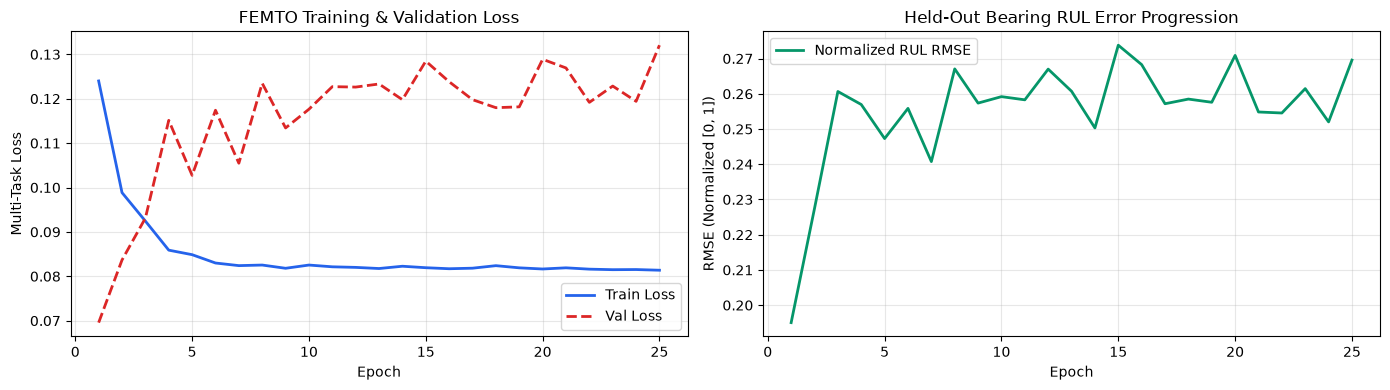

In [9]:
hist_df = pd.DataFrame(history)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(hist_df['epoch'], hist_df['train_loss'], label='Train Loss', color='#2563eb', lw=2)
ax1.plot(hist_df['epoch'], hist_df['val_loss'], label='Val Loss', color='#dc2626', lw=2, ls='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Multi-Task Loss')
ax1.set_title('FEMTO Training & Validation Loss')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(hist_df['epoch'], hist_df['rmse'], label='Normalized RUL RMSE', color='#059669', lw=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('RMSE (Normalized [0, 1])')
ax2.set_title('Held-Out Bearing RUL Error Progression')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


## 9. Full Diagnostic Inference on Held-Out Validation Bearing
Generate Remaining Useful Life with uncertainty envelope ($p_{10}, p_{50}, p_{90}$), Health Index, and Anomaly Probabilities.


In [10]:
def anomaly_probability(error: float, threshold: float, scale: float) -> float:
    z = (error - threshold) / max(scale, 1e-6)
    return float(1.0 / (1.0 + np.exp(-np.clip(z, -10, 10))))

def lifecycle_stage(health: float, anomaly_prob: float) -> str:
    if health >= 80 and anomaly_prob < 30:
        return "Nominal / Baseline"
    elif health >= 50 and anomaly_prob < 60:
        return "Early Degradation"
    elif health >= 20:
        return "Accelerated Wear"
    else:
        return "Critical Pre-Failure"

def maintenance_action(health: float, rul_p10: float, rul_p50: float, anomaly_prob: float) -> str:
    if health < 25 or anomaly_prob > 80:
        return "IMMEDIATE SHUTDOWN & INSPECTION REQUIRED"
    elif health < 50 or rul_p10 < 20:
        return "Schedule replacement during next maintenance window"
    elif anomaly_prob > 50:
        return "Increase vibration sampling frequency & monitor thermal trend"
    return "Normal operation; continue regular monitoring"

def run_notebook_inference(d_in: pd.DataFrame, checkpoint: dict, model_in: nn.Module) -> pd.DataFrame:
    d = d_in.sort_values(['bearing_id', 'time_idx']).reset_index(drop=True)
    feats = checkpoint['features']
    conds = checkpoint['condition_cols']
    
    X = d[feats].replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy(np.float32)
    X = (X - np.asarray(checkpoint['feature_mean'])) / (np.asarray(checkpoint['feature_std']) + 1e-6)
    C = d[conds].replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy(np.float32)
    C = (C - np.asarray(checkpoint['cond_mean'])) / (np.asarray(checkpoint['cond_std']) + 1e-6)
    
    w = int(checkpoint['config']['window'])
    rscale = checkpoint.get('rul_scale', 1.0)
    thresh = checkpoint.get('anomaly_threshold', 0.02)
    ascale = checkpoint.get('anomaly_scale', 0.01)
    
    pad_len = max(0, w - len(d))
    if pad_len > 0:
        X_padded = np.pad(X, ((pad_len, 0), (0, 0)), mode='edge')
        C_padded = np.pad(C, ((pad_len, 0), (0, 0)), mode='edge')
        indices = [len(d) - 1]
    else:
        X_padded, C_padded = X, C
        indices = list(range(w - 1, len(d)))

    batch_X = torch.stack([torch.from_numpy(X_padded[idx + pad_len - w + 1 : idx + pad_len + 1]) for idx in indices])
    batch_C = torch.stack([torch.from_numpy(C_padded[idx + pad_len - w + 1 : idx + pad_len + 1]) for idx in indices])
    
    model_in.eval()
    with torch.no_grad():
        out = model_in(batch_X, batch_C)
        h_arr = out['health'].squeeze(-1).numpy() if out['health'].ndim > 1 else out['health'].numpy()
        rul_arr = out['rul'].numpy()
        rec_arr = torch.mean((out['reconstruction'] - batch_X[:, -1, :]) ** 2, dim=-1).numpy()
    
    rows = []
    for i, end in enumerate(indices):
        h = float(h_arr[i])
        q = rul_arr[i]
        rec = float(rec_arr[i])
        a = anomaly_probability(rec, thresh, ascale)
        rows.append({
            'time_idx': d.loc[end, 'time_idx'],
            'true_rul_native': float(d.loc[end, 'rul_raw']) if 'rul_raw' in d.columns else np.nan,
            'health_pct': 100.0 * h,
            'rul_p10_native': float(q[0] * rscale),
            'rul_p50_native': float(q[1] * rscale),
            'rul_p90_native': float(q[2] * rscale),
            'anomaly_pct': 100.0 * a,
            'reconstruction_error': rec,
            'stage': lifecycle_stage(100 * h, 100 * a),
            'action': maintenance_action(100 * h, 100 * float(q[0]), 100 * float(q[1]), 100 * a)
        })
    return pd.DataFrame(rows)

results = run_notebook_inference(val_df, saved_ckpt, model)
print(f"Validation inference generated for bearing {val_bearing_id} ({len(results)} timesteps):")
results[['time_idx', 'true_rul_native', 'rul_p50_native', 'health_pct', 'anomaly_pct', 'stage']].tail(5)


Validation inference generated for bearing Bearing3_2 (1606 timesteps):


,time_idx,true_rul_native,rul_p50_native,health_pct,anomaly_pct,stage
1601,1632,4.0,514.548279,20.882198,0.00454,Accelerated Wear
1602,1633,3.0,514.548279,20.882198,0.00454,Accelerated Wear
1603,1634,2.0,514.548279,20.882198,0.00454,Accelerated Wear
1604,1635,1.0,514.548279,20.882198,0.00454,Accelerated Wear
1605,1636,0.0,514.548279,20.882198,0.00454,Accelerated Wear


## 10. Multi-Panel Diagnostic Trajectory Plot
Visualize the run-to-failure lifetime profile for the held-out bearing.


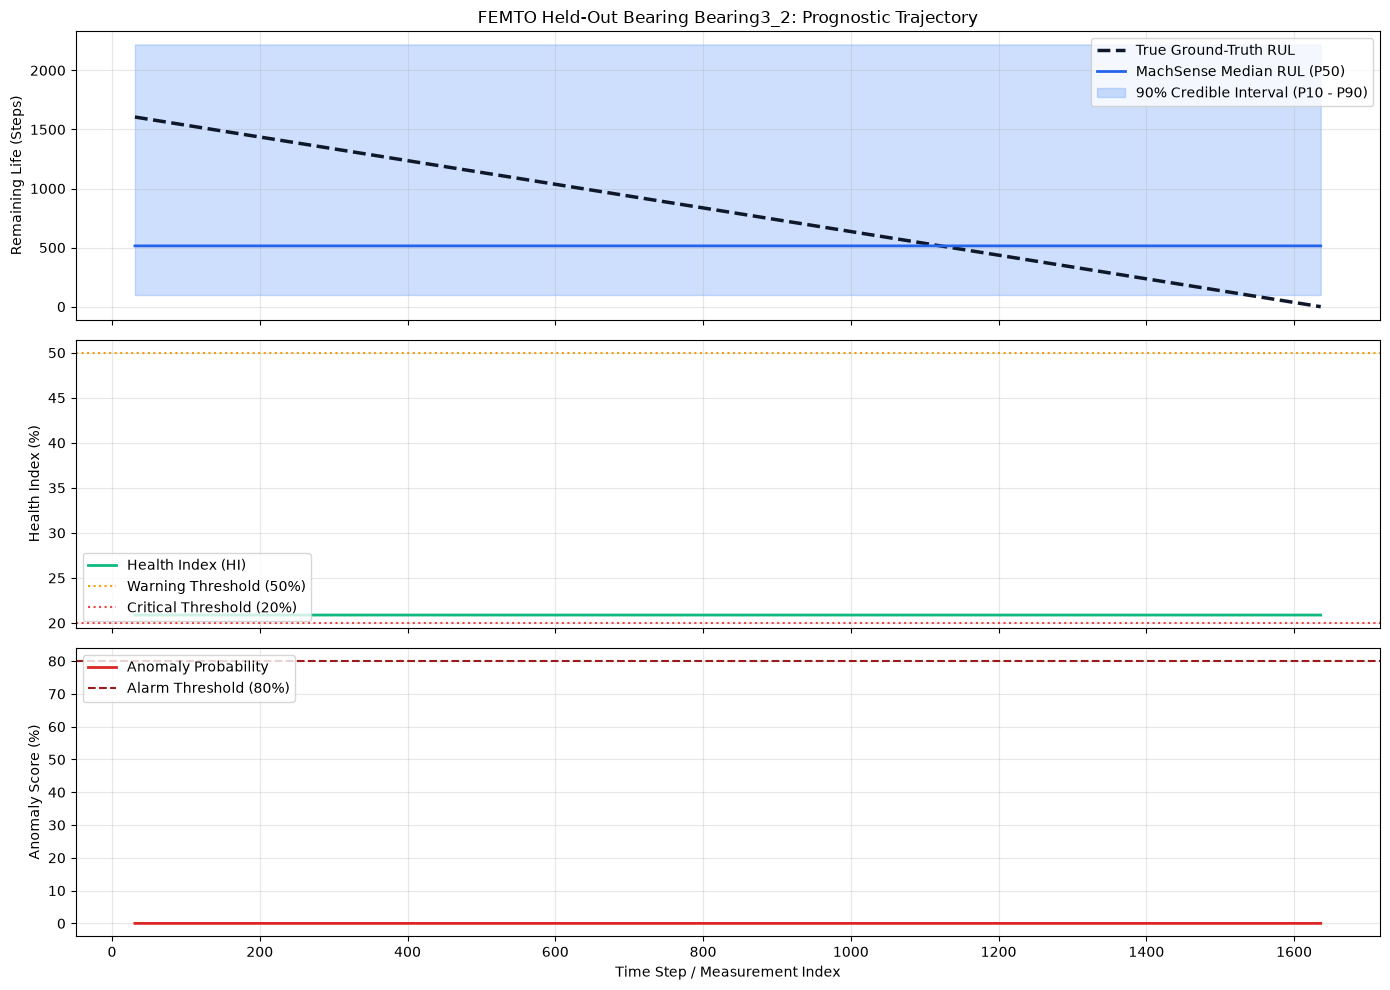

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 1. RUL with Quantile Confidence Bounds
ax1.plot(results['time_idx'], results['true_rul_native'], label='True Ground-Truth RUL', color='#0f172a', lw=2.5, ls='--')
ax1.plot(results['time_idx'], results['rul_p50_native'], label='MachSense Median RUL (P50)', color='#2563eb', lw=2)
ax1.fill_between(results['time_idx'], results['rul_p10_native'], results['rul_p90_native'], 
                 color='#3b82f6', alpha=0.25, label='90% Credible Interval (P10 - P90)')
ax1.set_ylabel('Remaining Life (Steps)')
ax1.set_title(f'FEMTO Held-Out Bearing {val_bearing_id}: Prognostic Trajectory')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

# 2. Continuous Health Index
ax2.plot(results['time_idx'], results['health_pct'], label='Health Index (HI)', color='#10b981', lw=2)
ax2.axhline(50, color='#f59e0b', ls=':', label='Warning Threshold (50%)')
ax2.axhline(20, color='#ef4444', ls=':', label='Critical Threshold (20%)')
ax2.set_ylabel('Health Index (%)')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='lower left')

# 3. Anomaly Probability & Alerts
ax3.plot(results['time_idx'], results['anomaly_pct'], label='Anomaly Probability', color='#dc2626', lw=2)
ax3.axhline(80, color='#991b1b', ls='--', label='Alarm Threshold (80%)')
ax3.set_ylabel('Anomaly Score (%)')
ax3.set_xlabel('Time Step / Measurement Index')
ax3.grid(True, alpha=0.3)
ax3.legend(loc='upper left')

plt.tight_layout()
plt.show()


## 11. Final Integrity Check
Confirm model checkpoint serialization format and consistency.


In [12]:
check_checkpoint(ckpt_path)
print(f"[OK] FEMTO benchmark notebook execution completed successfully!")


[OK] FEMTO benchmark notebook execution completed successfully!
